In [1]:
!python --version

Python 3.12.10


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Практичне завдання №1: Симуляція обробки сигналу фотонним сплітером

In [3]:
def simulate_beam_splitter(
    k: float,
    a1: float, phi1: float,
    a2: float, phi2: float
) -> tuple[float, float, float, float, float]:
    """
    Матрична симуляція обробки сигналу фотонним сплітером.
    Повертає: (a_out1, phi_out1, a_out2, phi_out2, delta_phi)
    """
    # Вектор комплексних сигналів на входах
    e_in = np.array([
        a1 * np.exp(1j * phi1),
        a2 * np.exp(1j * phi2)
    ])

    # Унітарна матриця переходу сплітера
    t = np.sqrt(1 - k)       # Коефіцієнт пропускання
    r = 1j * np.sqrt(k)      # Коефіцієнт відбиття (зсув на pi/2)

    splitter_matrix = np.array([
        [t, r],
        [r, t]
    ])

    # Вектор сигналів на виходах
    e_out = splitter_matrix @ e_in

    # Витягуємо нові амплітуди та фази
    a_out = np.abs(e_out)
    phi_out = np.angle(e_out)

    # Нормалізація різниці фаз до діапазону [-pi, pi]
    delta_phi = np.angle(np.exp(1j * (phi_out[1] - phi_out[0])))

    return a_out[0], phi_out[0], a_out[1], phi_out[1], delta_phi

## Запуск симуляції та вивід числових результатів

In [4]:
# Задаємо параметри за варіантом
K_SPLITTER = 0.5

AMP_1, PHASE_1 = 1.0, 0.0          # Вхід 1
AMP_2, PHASE_2 = 1.0, np.pi / 2    # Вхід 2

# Виконуємо розрахунок
a_out1, phi_out1, a_out2, phi_out2, delta_phi = simulate_beam_splitter(
    K_SPLITTER, AMP_1, PHASE_1, AMP_2, PHASE_2
)

print("=== Результати симуляції ===")
print(f"Коефіцієнт k = {K_SPLITTER}\n")
print(f"Вихід 1: Амплітуда = {a_out1:.4f}, Фаза = {np.degrees(phi_out1):.2f}°")
print(f"Вихід 2: Амплітуда = {a_out2:.4f}, Фаза = {np.degrees(phi_out2):.2f}°")
print(f"Різниця фаз (Δϕ): {np.degrees(delta_phi):.2f}°")

=== Результати симуляції ===
Коефіцієнт k = 0.5

Вихід 1: Амплітуда = 0.0000, Фаза = 90.00°
Вихід 2: Амплітуда = 1.4142, Фаза = 90.00°
Різниця фаз (Δϕ): 0.00°


## Візуалізація сигналів

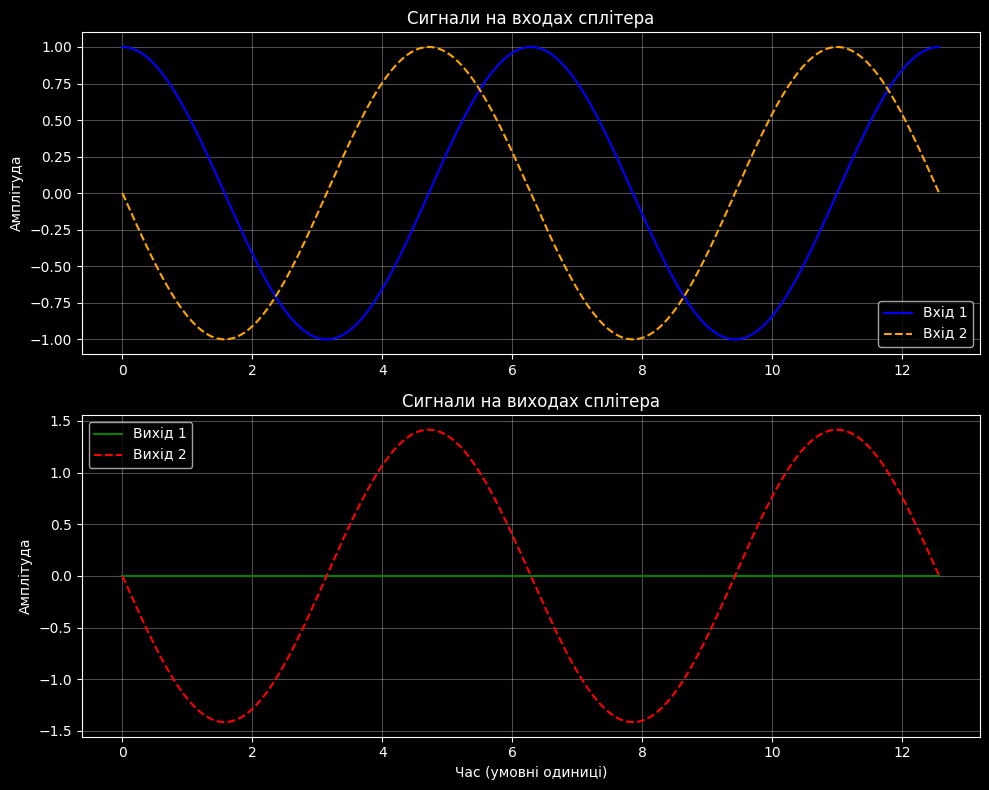

In [5]:
# Налаштування часу для побудови графіків (2 періоди)
t_time = np.linspace(0, 4 * np.pi, 500)

# Функція генерації хвилі E(t) = A * cos(w*t + phi)
def generate_wave(amp, phase, t):
    return amp * np.cos(t + phase)

# Генеруємо масиви точок для графіків
wave_in1 = generate_wave(AMP_1, PHASE_1, t_time)
wave_in2 = generate_wave(AMP_2, PHASE_2, t_time)
wave_out1 = generate_wave(a_out1, phi_out1, t_time)
wave_out2 = generate_wave(a_out2, phi_out2, t_time)

# Побудова
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(t_time, wave_in1, label='Вхід 1', color='blue')
ax1.plot(t_time, wave_in2, label='Вхід 2', color='orange', linestyle='--')
ax1.set_title('Сигнали на входах сплітера')
ax1.set_ylabel('Амплітуда')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(t_time, wave_out1, label='Вихід 1', color='green')
ax2.plot(t_time, wave_out2, label='Вихід 2', color='red', linestyle='--')
ax2.set_title('Сигнали на виходах сплітера')
ax2.set_xlabel('Час (умовні одиниці)')
ax2.set_ylabel('Амплітуда')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()